<a href="https://colab.research.google.com/github/Uday-SR/CNN/blob/main/Build_a_CNN_for_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_dir = '/content/drive/MyDrive/Datasets/flowers'
os.listdir(data_dir)

['tulip', 'sunflower', 'rose', 'dandelion', 'daisy']

In [ ]:
batch_size = 32
img_height = 128
img_width = 128

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 4317 files belonging to 5 classes.
Using 3454 files for training.
Found 4317 files belonging to 5 classes.
Using 863 files for validation.


In [ ]:
class_names = train_ds.class_names
print(class_names)

['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


In [ ]:
# Normalize image pixel values.

normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [ ]:
#Create a CNNusingConv2D, MaxPooling2D,Flatten, and Dense layers

model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu',
                  input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(5, activation='softmax')
])

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train the model

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=30
)

Epoch 1/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 556s 5s/step - accuracy: 0.4311 - loss: 1.3178 - val_accuracy: 0.5203 - val_loss: 1.1006
Epoch 2/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 90s 833ms/step - accuracy: 0.5964 - loss: 1.0087 - val_accuracy: 0.6107 - val_loss: 0.9957
Epoch 3/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 95s 881ms/step - accuracy: 0.6546 - loss: 0.8770 - val_accuracy: 0.6304 - val_loss: 0.9587
Epoch 4/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 92s 845ms/step - accuracy: 0.7186 - loss: 0.7432 - val_accuracy: 0.6315 - val_loss: 0.9840
Epoch 5/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 94s 868ms/step - accuracy: 0.7721 - loss: 0.5987 - val_accuracy: 0.6396 - val_loss: 1.0282
Epoch 6/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 142s 874ms/step - accuracy: 0.8474 - loss: 0.4243 - val_accuracy: 0.6559 - val_loss: 1.0895
Epoch 7/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 94s 873ms/step - accuracy: 0.9042 - loss: 0.2737 - val_accuracy: 0.6616 - val_loss: 1.2652
Epoch 8/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 138s 835ms/step - accuracy: 0.9421 - loss: 0

In [ ]:
# Record training and testing accuracy.

train_loss, train_acc = model.evaluate(train_ds)

test_loss, test_acc = model.evaluate(test_ds)

print("Training Accuracy:", train_acc)

print("Testing Accuracy:", test_acc)

108/108 ━━━━━━━━━━━━━━━━━━━━ 29s 272ms/step - accuracy: 0.9997 - loss: 7.0805e-04
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 291ms/step - accuracy: 0.6767 - loss: 2.7978
Training Accuracy: 0.9997105002403259
Testing Accuracy: 0.6767091751098633


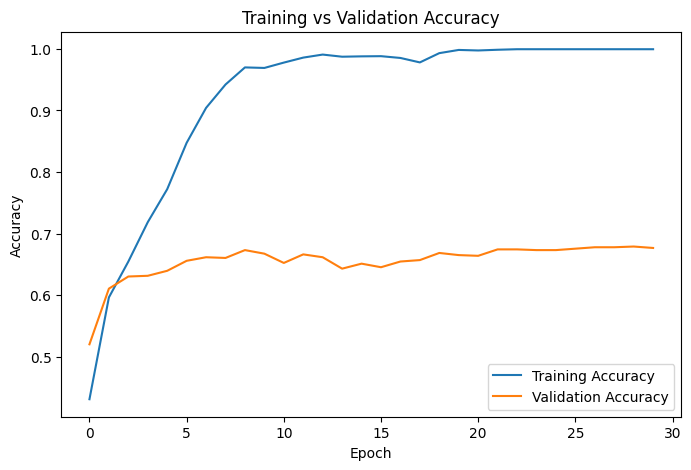

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()